### Read the SNOWPACK TKG4 WY2024 Simulations

created by Cassie Lumbrazo\
last updated: March 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tkg4'

## Put Some JIF Data info a simple dataframe to plot later

In [3]:
# create a new dataframe with field data above 
# site name = TKG4 
# date = 2024-06-15, as in, June 15, 2024
# total core depth = 800 cm 
# snow-firm transition depth = 642.5 cm 

df_field = pd.DataFrame({
    'date': ['2024-06-15'],
    'site': ['TKG4'],
    'core_depth_cm': [800],
    'snow_firm_transition_depth_cm': [642.5]
})

# df_field date to datetime
df_field['date'] = pd.to_datetime(df_field['date'])
df_field


,date,site,core_depth_cm,snow_firm_transition_depth_cm
0,2024-06-15,TKG4,800,642.5


# Open Data and Model Simulations

## Function for Reading SMET Files 

In [4]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

## Open SNOWPACK SMet Output for WY2024 only

In [5]:
ds_snowpack_WY2024, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tkg4/output/hrrrak_tkg4_WY2024_heatflux_soiltemp_zero.smet")

print(ds_snowpack_WY2024)
print(header)

<xarray.Dataset> Size: 4MB
Dimensions:               (timestamp: 8784)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 70kB 2023-10-01T05:00:00...
Data variables: (12/63)
    Qs                    (timestamp) float64 70kB 5.416 1.237 ... 32.43 24.35
    Ql                    (timestamp) float64 70kB -6.318 -0.443 ... 306.9 118.3
    Qg                    (timestamp) float64 70kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 70kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 70kB 3.073 2.183 1.734 ... 0.0 0.0
    Qr                    (timestamp) float64 70kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                    ...
    zSs                   (timestamp) float64 70kB 2.661 5.156 ... 207.8 207.8
    Ss                    (timestamp) float64 70kB 6.0 6.0 6.0 ... 0.201 0.336
    zS4                   (timestamp) float64 70kB 2.661 5.156 ... 207.8 207.8
    S4                    (timestamp) float64 70kB 6.0 6.0 6.0 ..

/tmp/ipykernel_3134062/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Text(0, 0.5, 'snow depth (cm)')

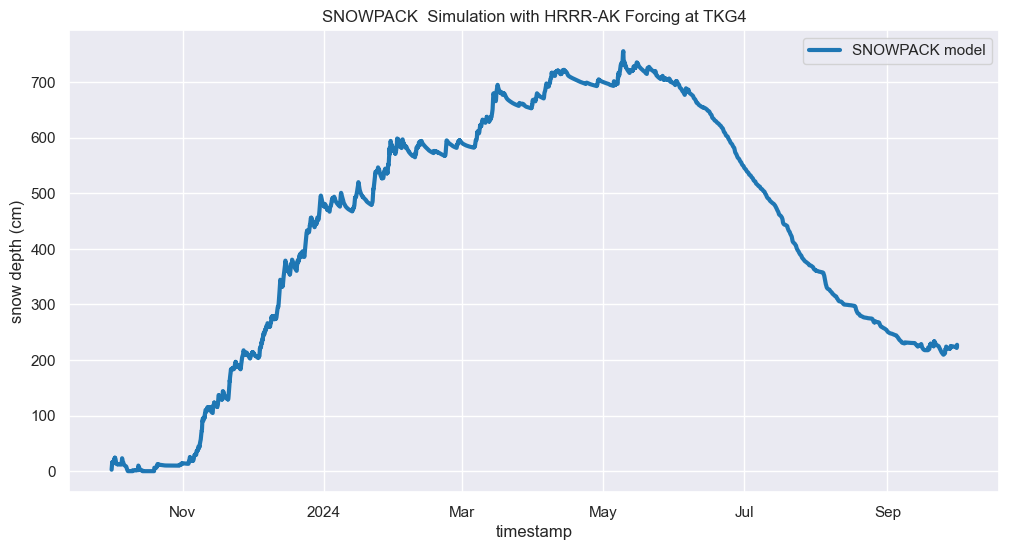

In [ ]:
ds_snowpack_WY2024.HS_mod.plot(label = 'SNOWPACK model', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at TKG4')
plt.legend()

plt.ylabel('snow depth (cm)')

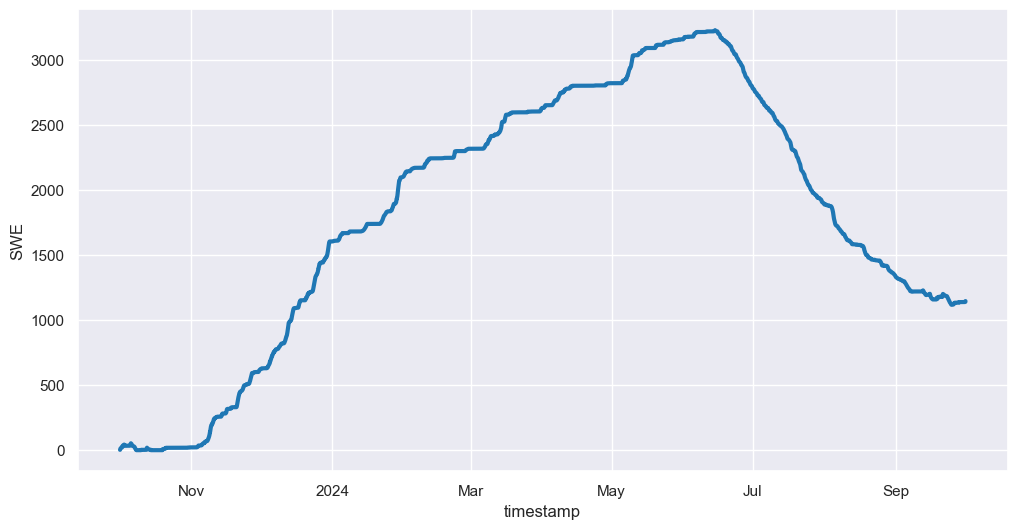

In [7]:
# plot SWE 
ds_snowpack_WY2024.SWE.plot(label = 'SNOWPACK model WY2024', linewidth = 3, color='tab:blue')

In [8]:
# loop through the variables in the dataset and print their names and dimensions
for var in ds_snowpack_WY2024.variables:
    print(f"Variable: {var}, Dimensions: {ds_snowpack_WY2024[var].dims}")

Variable: Qs, Dimensions: ('timestamp',)
Variable: Ql, Dimensions: ('timestamp',)
Variable: Qg, Dimensions: ('timestamp',)
Variable: TSG, Dimensions: ('timestamp',)
Variable: Qg0, Dimensions: ('timestamp',)
Variable: Qr, Dimensions: ('timestamp',)
Variable: dIntEnergySnow, Dimensions: ('timestamp',)
Variable: meltFreezeEnergySnow, Dimensions: ('timestamp',)
Variable: ColdContentSnow, Dimensions: ('timestamp',)
Variable: OLWR, Dimensions: ('timestamp',)
Variable: ILWR, Dimensions: ('timestamp',)
Variable: LWR_net, Dimensions: ('timestamp',)
Variable: OSWR, Dimensions: ('timestamp',)
Variable: ISWR, Dimensions: ('timestamp',)
Variable: Qw, Dimensions: ('timestamp',)
Variable: pAlbedo, Dimensions: ('timestamp',)
Variable: mAlbedo, Dimensions: ('timestamp',)
Variable: ISWR_h, Dimensions: ('timestamp',)
Variable: ISWR_dir, Dimensions: ('timestamp',)
Variable: ISWR_diff, Dimensions: ('timestamp',)
Variable: TA, Dimensions: ('timestamp',)
Variable: TSS_mod, Dimensions: ('timestamp',)
Variable

In [9]:
ls

2_create_snowpack_smet_forcing_hrrrak_tkg4_WY2020-WY2025.ipynb
2_create_snowpack_smet_forcing_hrrrak_tkg4_WY2024.ipynb
2_create_snowpack_smet_forcing_hrrrak_tkg4_WY2024-WY2025.ipynb
3_read_snowpack_output_WY2020-WY2025.ipynb
3_read_snowpack_output_WY2024-25.ipynb
4_read_snowpack_output_other_files.ipynb


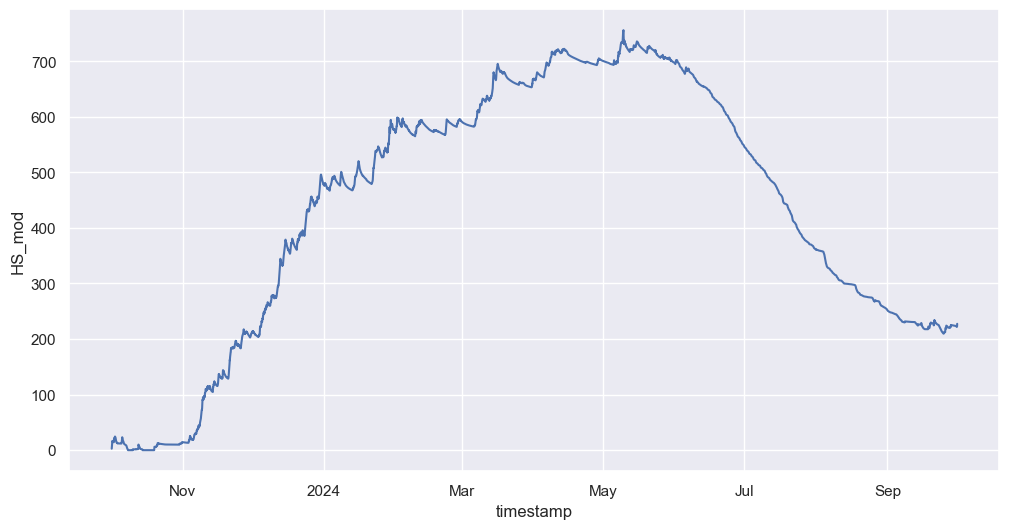

In [10]:
ds_snowpack_WY2024.HS_mod.plot()

Text(0.5, 1.0, 'SNOWPACK  Simulation with HRRR-AK Forcing at TKG4')

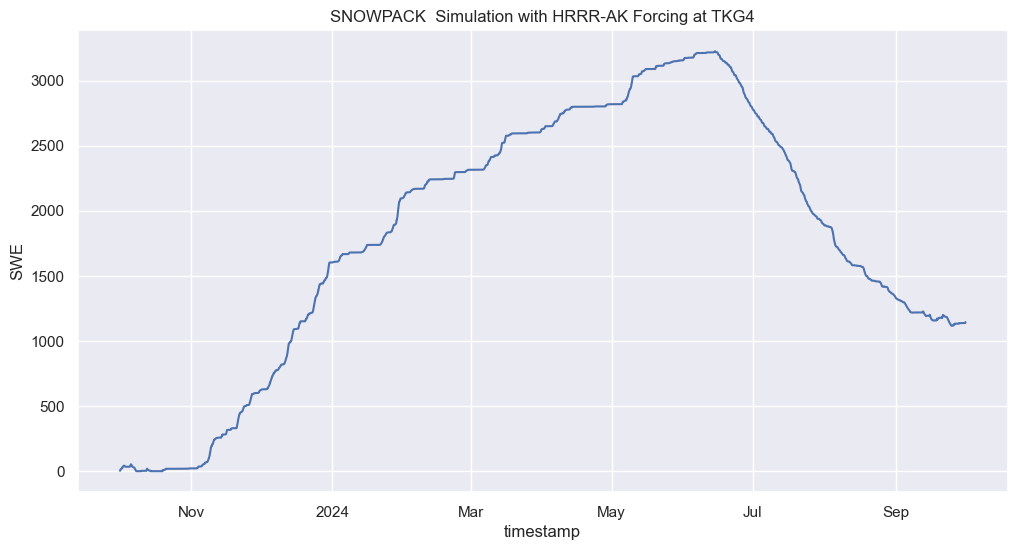

In [14]:

ds_snowpack_WY2024.SWE.plot()
plt.title('SNOWPACK  Simulation with HRRR-AK Forcing at TKG4')


# Try snowpat

In [12]:
from snowpat.snowpackreader import SnowpackReader

reader = SnowpackReader("/home/cassie/python/models/run_snowpack/sites/tkg4/output/hrrrak_tkg4_WY2024-25_heatflux_soiltemp_zero.pro")
profiles = reader.get_profiles()

ModuleNotFoundError: No module named 'snowpat'